# MGSC 661 - Predicting Movie Opening-Weekend Revenue


 

## Setup

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
from IPython.display import display

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_white
from scipy.stats import shapiro

from ISLP.models import (ModelSpec as MS,
                         summarize)

In [3]:
df = pd.read_excel("movie_training_data_student.xlsx", sheet_name="Training_Data")
df.head()

,movie_id,title,release_date,release_year,release_month,release_quarter,opening_weekend_revenue_musd,production_budget_musd,opening_theaters,runtime_minutes,...,holiday_release,source_dataset,source_url,audience_score,domestic_box_office_musd,foreign_box_office_musd,worldwide_box_office_musd,opening_revenue_per_theater_kusd,opening_budget_recovery_pct,worldwide_budget_recovery_pct
0,TRN-0001,Escape Room,2019-01-04,2019,1,Q1,18.238172,9.0,2717,109.0,...,0,The Numbers release schedule and movie page; L...,https://www.the-numbers.com/movie/Escape-Room-...,54.0,57.00,98.61,155.62,6.712614,2.026464,17.291111
1,TRN-0002,A Dog’s Way Home,2019-01-11,2019,1,Q1,11.251263,61.0,3090,102.0,...,0,The Numbers release schedule and movie page; L...,https://www.the-numbers.com/movie/Dogs-Way-Hom...,71.0,41.95,39.20,81.15,3.641185,0.184447,1.330328
2,TRN-0003,Replicas,2019-01-11,2019,1,Q1,2.375325,30.0,2329,107.0,...,0,The Numbers release schedule and movie page,https://www.the-numbers.com/movie/Replicas-(2018),NaN,NaN,NaN,NaN,1.019891,0.079177,NaN
3,TRN-0004,Dragon Ball Super: Broly,2019-01-16,2019,1,Q1,9.816197,8.5,1247,100.0,...,0,The Numbers release schedule and movie page,https://www.the-numbers.com/movie/Dragon-Ball-...,NaN,NaN,NaN,NaN,7.871850,1.154847,NaN
4,TRN-0005,Glass,2019-01-18,2019,1,Q1,40.328920,20.0,3841,128.0,...,0,The Numbers release schedule and movie page; L...,https://www.the-numbers.com/movie/Glass-(2019),66.0,111.05,135.95,247.00,10.499589,2.016446,12.350000


# Part 1. Conduct an initial assessment of the data

## Question 1. Report the number of observations and variables

In [4]:
n_observations, n_variables = df.shape

print("Number of observations:", n_observations)
print("Number of variables:", n_variables)

Number of observations: 359
Number of variables: 29


The dataset has 359 movies and 29 variables, covering domestic wide releases in 2019 and from 2022 to 2025. Revenue, budget and theaters are complete, while runtime and rating each have 5 missing values. The recoveries are stored as percentages and two derived fields are calculated directly from opening revenue.

## Question 2. Create a missing-value report

In [5]:
missing_number_by_column = df.isna().sum()
missing_percentage_by_column = df.isna().mean() * 100

missing_report = pd.DataFrame({
    "Missing number": missing_number_by_column,
    "Missing percentage": missing_percentage_by_column
}).round(2)

missing_report.index.name = "Variable"
missing_report



,Missing number,Missing percentage
Variable,,
movie_id,0,0.00
title,0,0.00
release_date,0,0.00
release_year,0,0.00
release_month,0,0.00
release_quarter,0,0.00
opening_weekend_revenue_musd,0,0.00
production_budget_musd,0,0.00
opening_theaters,0,0.00


## Question 3. Report descriptive statistics for the numerical variables

In [ ]:
numerical_variables = df.select_dtypes(include="number").columns


summary = df[numerical_variables].describe().T

descriptive_statistics = pd.DataFrame({
    "Range": summary["max"] - summary["min"],
    "Mean": summary["mean"],
    "Min": summary["min"],
    "Max": summary["max"]
}).round(3)

descriptive_statistics.index.name = "Variable"
descriptive_statistics

,Range,Mean,Min,Max
Variable,,,,
release_year,6.000,2022.432,2019.000,2025.000
release_month,11.000,6.735,1.000,12.000
opening_weekend_revenue_musd,356.864,29.555,0.251,357.115
production_budget_musd,399.985,67.761,0.015,400.000
opening_theaters,4075.000,3211.900,660.000,4735.000
runtime_minutes,113.000,115.384,84.000,197.000
summer_release,1.000,0.248,0.000,1.000
holiday_release,1.000,0.187,0.000,1.000
audience_score,68.000,79.460,31.000,99.000


# Part 2. Estimate and interpret the baseline model

## Question 4. Prepare the baseline-model sample

In [ ]:
baseline_variables = [
    "opening_weekend_revenue_musd",
    "production_budget_musd",
    "opening_theaters",
    "runtime_minutes"
]


baseline_data = df.dropna(subset=baseline_variables).copy()

print("Baseline sample size:", len(baseline_data))
print("Observations removed:", len(df) - len(baseline_data))

 

Baseline sample size: 354
Observations removed: 5


Rows missing any baseline variable were dropped. The final sample has 354 movies and 5 observations were removed, all because runtime minutes was missing.

## Question 5. Estimate and report the full baseline model

In [ ]:
baseline_predictors = [
    "production_budget_musd",
    "opening_theaters",
    "runtime_minutes"
]

design_baseline = MS(baseline_predictors)
X_baseline = design_baseline.fit_transform(baseline_data)
y_baseline = baseline_data["opening_weekend_revenue_musd"] 

baseline_model = sm.OLS(y_baseline, X_baseline)
baseline_results = baseline_model.fit()

display(summarize(baseline_results))
print("R-squared:", round(baseline_results.rsquared, 4))
print("Residual standard error:", round(np.sqrt(baseline_results.scale), 4))



,coef,std err,t,P>|t|
intercept,-48.7159,11.848,-4.112,0.000
production_budget_musd,0.2760,0.030,9.116,0.000
opening_theaters,0.0142,0.002,6.448,0.000
runtime_minutes,0.1242,0.086,1.439,0.151


R-squared: 0.5263
Residual standard error: 28.7651


R squared is 0.526, essentially the budget, opening theaters and runtime all together can explain about 52.6% of the variation in opening weekend revenue. The residual standard error is $28.77 million, this is bad because the average opening weekend is $29.6 million, So if the prediction for a movie is $30.0 million in reality it could be anywhere form $0 to $60.0 million. Predictions for individual movies are imprecise despite the moderate R squared.

## Question 6. Interpret all coefficients in the baseline model

Keeping variables like opening theaters and runtime constant, every $1 million of additional production budget is associated with an increase of about $0.28 million so just about $280,000.00 in expected opening weekend revenue. Holding budget and runtime constant, one extra theatre adds $14,200 more to the predicted opening weekend revenue. Each additional minute of adds $120,000 to the prediction, holding the other predictors constant, but because the p value is greater than 0.05 we cant be sure if its significant. The intercept −$48.7 million is the predicted revenue for a movie with zero budget, theaters and runtime; it has no practical meaning because such a movie lies far outside the data the smallest opening is 660 theaters.

## Question 7. Remove insignificant predictors and re-estimate the model

In [ ]:

p_values = baseline_results.pvalues.drop("intercept")
significant_predictors = p_values[p_values < 0.05].index.tolist()

print("Significant predictors:", significant_predictors)


Significant predictors: ['production_budget_musd', 'opening_theaters']


In [ ]:

design_reduced = MS(significant_predictors)
X_reduced = design_reduced.fit_transform(baseline_data)
reduced_model = sm.OLS(y_baseline, X_reduced)
reduced_results = reduced_model.fit()

display(summarize(reduced_results))
print("R-squared:", round(reduced_results.rsquared, 4))
print("Residual standard error:", round(np.sqrt(reduced_results.scale), 4))



,coef,std err,t,P>|t|
intercept,-34.2288,6.255,-5.472,0.0
production_budget_musd,0.2970,0.027,11.178,0.0
opening_theaters,0.0137,0.002,6.291,0.0


R-squared: 0.5235
Residual standard error: 28.8089


Runtime was removed because its p = 0.151 which exceeeds the 5% significance level. R squared falls only from 0.526 in the full model to 0.524 in this simplified model and the residual standard error increases slightly from $28.77M to $28.81M.The budget coefficient increases from 0.276 to 0.297, suggesting that runtime and budget are correlated and budget now captures part of runtime's association with revenue.


# Part 3. Assess the baseline model and its assumptions

## Question 8. Assess linearity using a residual-versus-fitted plot

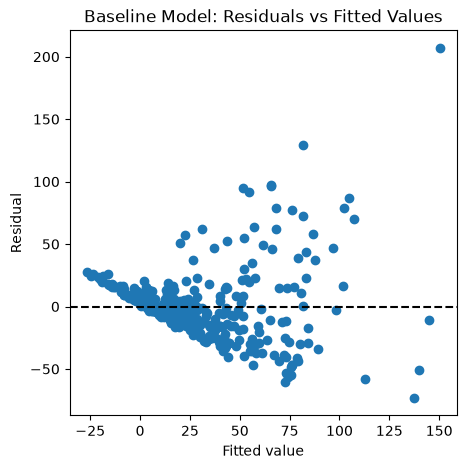

Movies with negative predicted revenue: 43


In [ ]:

ax = subplots(figsize=(5,5))[1]
ax.scatter(baseline_results.fittedvalues, baseline_results.resid)

ax.axhline(0, c='k', ls='--')
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.set_title('Baseline Model: Residuals vs Fitted Values')
plt.show()

print("Movies with negative predicted revenue:", (baseline_results.fittedvalues < 0).sum())

The residuals dont form random pattern around 0, they have a curved pattern. The model also predicts negative revenue for 43 movies, these form a straight diagonal band on the left. This indicates the relationship is not linear. 

## Question 9. Calculate and interpret the Durbin-Watson statistic

In [ ]:



dw_df = baseline_data[["release_date"]].copy()
dw_df["residual"] = baseline_results.resid
dw_df = dw_df.sort_values("release_date").reset_index(drop=True)

dw_statistic = durbin_watson(dw_df["residual"])
print("Durbin-Watson statistic (release-date order):", round(dw_statistic, 4))
 

 

Durbin-Watson statistic (release-date order): 1.9864


After ordering the residuals by release date, the Durbin Watson statistic is 1.986. This shows that a movie's prediction error is essentially unrelated to the error of the movie released just before it,. There isnt evidence of autocorrelation.

## Question 10. Assess constant error variance using White's test

In [ ]:

white_test = het_white(baseline_results.resid, baseline_results.model.exog)
white_labels = ["LM statistic", "LM p-value", "F statistic", "F p-value"]

white_results = pd.Series(white_test, index=white_labels)
print("LM stat, LM p-value, F-stat, F p-value:", tuple(float(x) for x in white_test))
white_results


LM stat, LM p-value, F-stat, F p-value: (129.70071386883825, 1.3664750427822227e-23, 22.101940640937507, 1.518326336453946e-29)


LM statistic    1.297007e+02
LM p-value      1.366475e-23
F statistic     2.210194e+01
F p-value       1.518326e-29
dtype: float64

The LM p value and the F p value are far below 0.05, so we reject H0 the error variance is not constant, and the errors get larger as predicted revenue increases. The null hypothesis is that the error variance is constant. We reject the null and conclude that the errors are not constant.

## Question 11. Assess normality using a Q-Q plot and the Shapiro-Wilk test

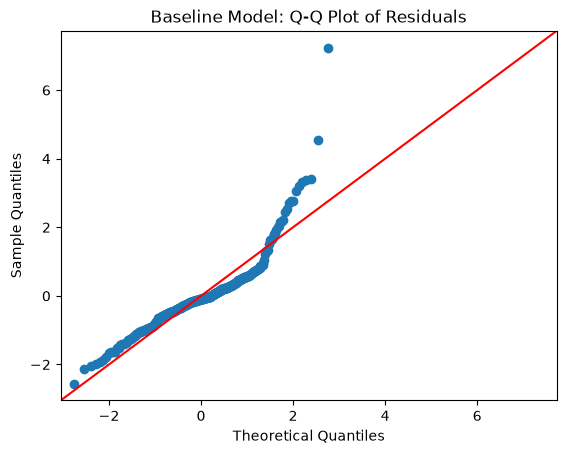

statistic, pvalue ShapiroResult(statistic=np.float64(0.8596696662887648), pvalue=np.float64(2.4937854556833492e-17))


In [16]:
sm.qqplot(baseline_results.resid, line="45", fit=True)
plt.title("Baseline Model: Q-Q Plot of Residuals")
plt.show()

shapiro_result = shapiro(baseline_results.resid)
print("statistic, pvalue", shapiro_result)


Q-Q plot: the residuals follow the 45 degree line in the middle but depart from it in the upper tail, where large positive residuals lie far above the line. THe Shapiro Wilk test null hypothesis is that the residuals are normally distributed. W = 0.860, not close to 1, and the p value is about 0.000000000000000025, so we reject null hypothesis because the residuals are not normal.

## Question 12. Identify high-leverage and influential observations

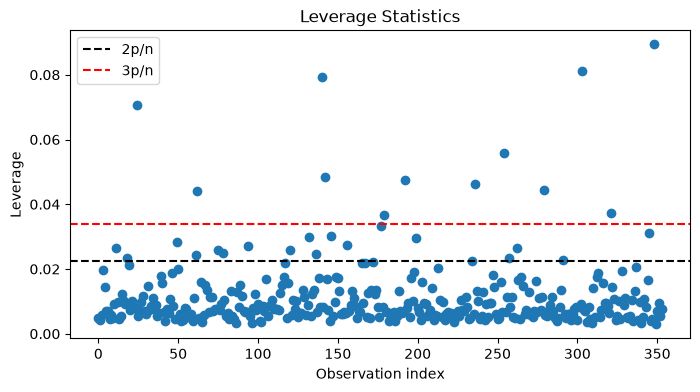

2p/n threshold: 0.0226
3p/n threshold: 0.0339
Movies above 2p/n: 30
Movies above 3p/n: 12
Highest leverage: Avatar: Fire and Ash


In [ ]:
influence = baseline_results.get_influence()
leverage = influence.hat_matrix_diag

n = X_baseline.shape[0]
p = X_baseline.shape[1]   
leverage_2pn = 2 * p / n
leverage_3pn = 3 * p / n

fig, ax = subplots(figsize=(8, 4))
ax.scatter(np.arange(n), leverage)
ax.axhline(leverage_2pn, color="black", linestyle="--", label="2p/n")
ax.axhline(leverage_3pn, color="red", linestyle="--", label="3p/n")
ax.set_xlabel("Observation index")
ax.set_ylabel("Leverage")
ax.set_title("Leverage Statistics")
ax.legend()
plt.show()

print("2p/n threshold:", round(leverage_2pn, 4))
print("3p/n threshold:", round(leverage_3pn, 4))
print("Movies above 2p/n:", int((leverage > leverage_2pn).sum()))
print("Movies above 3p/n:", int((leverage > leverage_3pn).sum()))

print("Highest leverage:", baseline_data["title"].iloc[np.argmax(leverage)])

With p = 4 and n = 354 the thresholds are 2p/n = 0.0226 and 3p/n = 0.0339. The movies with the highest leverage are Avatar Fire and Ash and Mission Impossible The Final Reckoning. Cook's distance: 31 movies are above 4/n = 0.011, mostly blockbusters the model misses by a wide margin. Avengers: Endgame is the only serious outlier. it combines high leverage with the largest residual, pulling the fitted line toward it. Avatar Fire and Ash and The Final Reckoning have higher leverage but D < 1, so high leverage does not necessarily imply strong influence. 

The main weakness of the model is that it misses a nonlinear pattern , its error variance is not constant, its residuals are not normal, and a few blockbusters strongly affect the fit. Its RSE (\$28.8M) is close to the average opening, so predictions should be used cautiously, especially for movies unlike the typical film in the sample.

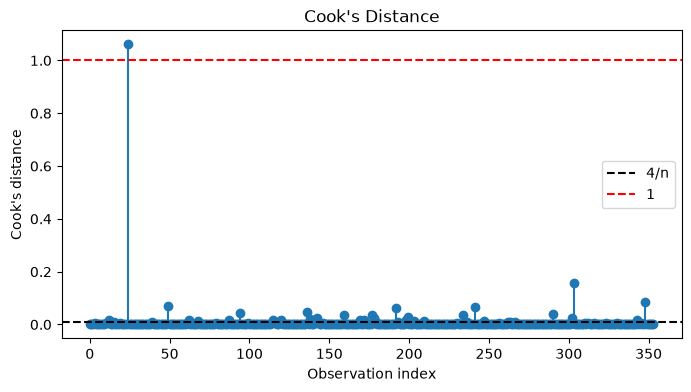

Movies with leverage above 3p/n:


Variable,title,opening_weekend_revenue_musd,production_budget_musd,opening_theaters,runtime_minutes,Leverage,Cook's distance
353,Avatar: Fire and Ash,89.1609,400.0,3800,197.0,0.0894,0.0839
308,Mission: Impossible—The Final Reckoning,64.0364,400.0,3857,169.0,0.0812,0.1559
143,Avatar: The Way of Water,134.1002,400.0,4202,190.0,0.0795,0.0032
24,Avengers: Endgame,357.1150,400.0,4662,181.0,0.0708,1.0604
259,Devara Part 1,5.6000,75.0,1040,178.0,0.0560,0.0002
145,Babylon,3.6034,80.0,3343,188.0,0.0484,0.0264
196,TAYLOR SWIFT | THE ERAS TOUR,93.2248,15.0,3855,168.0,0.0474,0.0614
241,Horizon: An American Saga Chapter 1,11.0526,50.0,3334,181.0,0.0464,0.0087
284,Ne Zha 2,7.2000,80.0,660,143.0,0.0446,0.0007
62,It: Chapter Two,91.0622,70.0,4570,169.0,0.0441,0.0176


Movies with Cook's distance above 4/n:


Variable,title,opening_weekend_revenue_musd,production_budget_musd,opening_theaters,runtime_minutes,Leverage,Cook's distance
24,Avengers: Endgame,357.1150,400.0,4662,181.0,0.0708,1.0604
308,Mission: Impossible—The Final Reckoning,64.0364,400.0,3857,169.0,0.0812,0.1559
353,Avatar: Fire and Ash,89.1609,400.0,3800,197.0,0.0894,0.0839
49,The Lion King,191.7708,260.0,4725,118.0,0.0283,0.0688
246,Deadpool & Wolverine,211.4353,200.0,4210,127.0,0.0128,0.0668
196,TAYLOR SWIFT | THE ERAS TOUR,93.2248,15.0,3855,168.0,0.0474,0.0614
139,Black Panther: Wakanda Forever,181.3398,250.0,4396,161.0,0.0246,0.0485
94,Star Wars: The Rise of Skywalker,177.3839,275.0,4406,142.0,0.0270,0.0425
295,A Minecraft Movie,162.7530,150.0,4263,100.0,0.0134,0.0394
239,Inside Out 2,154.2017,200.0,4440,100.0,0.0226,0.0374


Movies with Cook's distance above 1:


Variable,title,opening_weekend_revenue_musd,production_budget_musd,opening_theaters,runtime_minutes,Leverage,Cook's distance
24,Avengers: Endgame,357.115,400.0,4662,181.0,0.0708,1.0604


In [21]:
# Cook's distance, following the lecture.
ols_influence = OLSInfluence(baseline_results)
cooks_distance, cooks_pvalue = ols_influence.cooks_distance
cook_threshold = 4 / n

fig, ax = subplots(figsize=(8, 4))
ax.stem(np.arange(n), cooks_distance, basefmt=" ")  #--- one stem per observation
ax.axhline(cook_threshold, color="black", linestyle="--", label="4/n")
ax.axhline(1, color="red", linestyle="--", label="1")
ax.set_xlabel("Observation index")
ax.set_ylabel("Cook's distance")
ax.set_title("Cook's Distance")
ax.legend()
plt.show()

influence_table = baseline_data[["title", "opening_weekend_revenue_musd",
                                 "production_budget_musd", "opening_theaters",
                                 "runtime_minutes"]].copy()
influence_table["Leverage"] = leverage
influence_table["Cook's distance"] = cooks_distance

very_high_leverage = influence_table[
    influence_table["Leverage"] > leverage_3pn
].sort_values("Leverage", ascending=False)  # leverage greater than 3p/n

large_cook = influence_table[
    influence_table["Cook's distance"] > cook_threshold
].sort_values("Cook's distance", ascending=False)  # Cook's distance greater than 4/n

serious_cook = influence_table[
    influence_table["Cook's distance"] > 1
].sort_values("Cook's distance", ascending=False)  # Cook's distance greater than 1

print("Movies with leverage above 3p/n:")
display(very_high_leverage.round(4))

print("Movies with Cook's distance above 4/n:")
display(large_cook.round(4))

print("Movies with Cook's distance above 1:")
display(serious_cook.round(4))

# Part 4. Design your own regression model

## Question 13. State Y and the candidate X variables before fitting models

## Question 14. Write and justify the final regression model

## Question 15. Describe and report the missing-value treatment

## Question 16. Create and display the y vector and X matrix

## Question 17. Estimate, report, and interpret the final model

## Question 18. Evaluate limitations and training-data prediction accuracy

# Part 5. Reflect on the use of AI